In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## data loading

In [33]:
data = pd.read_csv('data/train.csv')
print(data.shape)

(42000, 785)


In [34]:
data = np.array(data)
m, n = data.shape
np.random.seed(42)
np.random.shuffle(data)

train_data = data[:int(m * 0.8), :]
val_data = data[int(m * 0.8):int(m * 0.9), :]
test_data = data[int(m * 0.9):, :]

def split_labels_pixels(dataset):
    dataset = dataset.T #transpose the dataset to make it easier to work with
    Y = dataset[0] #first row is the labels
    X = dataset[1:] / 255.0
    return X, Y

X_train, Y_train = split_labels_pixels(train_data)
X_val, Y_val = split_labels_pixels(val_data)
X_test, Y_test = split_labels_pixels(test_data)

print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)

(784, 33600) (33600,)
(784, 4200) (4200,)
(784, 4200) (4200,)


## initializing parameters

In [35]:
def init_params(layer_sizes, seed=None):
    rng = np.random.default_rng(seed)
    
    W = []
    b = []
    for i in range(len(layer_sizes) - 1):
        input_size = layer_sizes[i]
        output_size = layer_sizes[i + 1]
        
        W.append(rng.uniform(-0.5, 0.5, (output_size, input_size)))
        b.append(rng.uniform(-0.5, 0.5, (output_size, 1)))
    
    return W, b

W, b = init_params([784, 10, 10])
for i, (w, bi) in enumerate(zip(W, b)):
    print(f"Layer {i+1}: W{w.shape}, b{bi.shape}")

Layer 1: W(10, 784), b(10, 1)
Layer 2: W(10, 10), b(10, 1)


## defining activation functions

In [36]:
def relu(Z):
    return np.maximum(0, Z)

def relu_deriv(Z):
    return (Z > 0)

def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)  # For numerical stability
    exp_Z = np.exp(Z)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

## propagating forward

In [43]:
def forward_prop(W, b, X):
    L = len(W)
    A = [X] # start with original input
    Z = [] # storing pre-activation values
    for i in range(L):
        z = W[i] @ A[-1] + b[i]
        a = relu(z) if i < L - 1 else softmax(z)
        Z.append(z)
        A.append(a)
    return Z, A

## one hot encoding?

In [44]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.max() + 1, Y.size))
    one_hot_Y[Y, np.arange(Y.size)] = 1
    return one_hot_Y

## backward propagation

In [45]:
def backward_prop(Z, A, W, Y, m_examples):
    L = len(W)
    one_hot_Y = one_hot(Y)
    dW, db = [None] * L, [None] * L
    dZ = A[-1] - one_hot_Y

    for i in reversed(range(L)):
        dW[i] = (1 / m_examples) * dZ @ A[i].T
        db[i] = (1 / m_examples) * np.sum(dZ, axis=1, keepdims=True)
        if i > 0:
            dZ = (W[i].T @ dZ) * relu_deriv(Z[i - 1])

    return dW, db

Z, A = forward_prop(W, b, X_train[:, :5])
print("W shapes:", [w.shape for w in W])
print("Z shapes:", [z.shape for z in Z])
print("A shapes:", [a.shape for a in A])
dW, db = backward_prop(Z, A, W, Y_train[:5], 5)
for i in range(len(W)):
    assert dW[i].shape == W[i].shape
    assert db[i].shape == b[i].shape
print("All gradient shapes match parameter shapes.")

W shapes: [(10, 784), (10, 10)]
Z shapes: [(10, 5), (10, 5)]
A shapes: [(784, 5), (10, 5), (10, 5)]
All gradient shapes match parameter shapes.


## update parameters

In [46]:
def update_params(W, b, dW, db, alpha):
    for i in range(len(W)):
        W[i] = W[i] - alpha * dW[i]
        b[i] = b[i] - alpha * db[i]
    return W, b

## predictions and accuracy

In [47]:
def get_predictions(A_final):
    return np.argmax(A_final, axis=0)

def get_accuracy(predictions, Y):
    return np.mean(predictions == Y)

## training loop

In [48]:
def train(X, Y, layer_sizes, alpha, iterations, seed=None):
    W, b = init_params(layer_sizes, seed=seed)
    m_examples = X.shape[1]
    
    for i in range(iterations):
        Z, A = forward_prop(W, b, X)
        dW, db = backward_prop(Z, A, W, Y, m_examples)
        W, b = update_params(W, b, dW, db, alpha)
        
        if i % 100 == 0:
            preds = get_predictions(A[-1])
            acc = get_accuracy(preds, Y)
            print(f"Iteration {i}: Accuracy = {acc:.4f}")
    
    return W, b

In [49]:
W, b = train(X_train, Y_train, layer_sizes=[784, 10, 10], alpha=0.10, iterations=500, seed=42)

Iteration 0: Accuracy = 0.1270
Iteration 100: Accuracy = 0.6655
Iteration 200: Accuracy = 0.7701
Iteration 300: Accuracy = 0.8109
Iteration 400: Accuracy = 0.8339


## evaluation

In [52]:
def make_predictions(X, W, b):
    _, A = forward_prop(W, b, X)
    return get_predictions(A[-1])

def test_prediction(index, X, Y, W, b):
    current_image = X[:, index, None]  # Keep it as a 2D array
    prediction = make_predictions(current_image, W, b)
    label = Y[index]
    print(f"Predicted: {prediction[0]}, Actual: {label}")
    plt.gray()
    plt.imshow(current_image.reshape((28, 28)) * 255, interpolation='nearest')
    plt.show()

Predicted: 8, Actual: 8


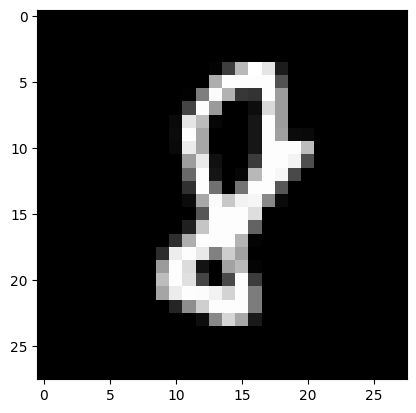

Predicted: 1, Actual: 1


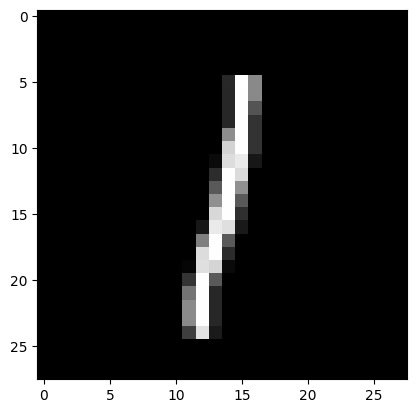

In [53]:
test_prediction(0, X_train, Y_train, W, b)
test_prediction(1, X_train, Y_train, W, b)

In [54]:
val_predictions = make_predictions(X_val, W, b)
print("Validation accuracy:", get_accuracy(val_predictions, Y_val))

test_predictions = make_predictions(X_test, W, b)
print("Test accuracy:", get_accuracy(test_predictions, Y_test))

Validation accuracy: 0.8464285714285714
Test accuracy: 0.8533333333333334
